In [152]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [153]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
from mpmath import mp, taylor, chebyfit, pade, nprint, polyval, cosh,mpf, sqrt, sech, sin, tan, atan
import numpy as np
# import pandas as pd
# from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

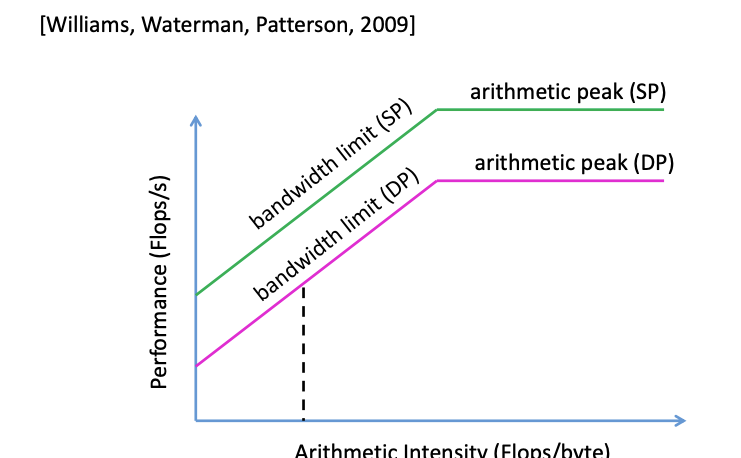

This is the loop I time
```
int tid = blockDim.x * blockIdx.x + threadIdx.x;
for (auto j=pack*tid; j<n; j+=pack*(gridDim.x * blockDim.x))  {
       for (int kk=0; kk<maxIter; ++kk) {
          for (int i=0; i<pack; ++i)
           f(outV,inV, ind, j+i, kk, n);
       }
}
```

and this is the computational "kernel" (f above)
```

template<typename T, typename F>
struct R {
   constexpr void operator()(SoA<T>  y, SoA<T> const x, int const * ind, int i, int k, int n) {
     F f;
     int j = ind[i];
     // assert(j>=0); assert(j<n);
     if constexpr (std::is_floating_point<T>::value)  {
      auto v = (y.x[i]*T(1.e-12))+x.x[j];
      auto w = (y.y[i]*T(1.e-12))+x.y[j];
      auto u = (y.z[i]*T(1.e-12))+x.z[j];
       y.x[i] =  f(v+w*u);
       y.y[i] =  f(w+v*u);
       y.z[i] =  f(u+v*w);
     } else  {
       auto v = float((y.x[i]>>15)+x.x[j]);
       auto w = float((y.y[i]>>15)+x.y[j]);
       auto u = float((y.z[i]>>15)+x.z[j]);
       y.x[i] =  f(v+w*u);
       y.y[i] =  f(w+v*u);
       y.z[i] =  f(u+v*w);
     }
   }
};
```
where F is either the identity or a polynomial of grade 9

In [154]:
times =np.array([
    [414825,169813,170148,303082,181781,143794,446454,236705,154211,443144,273051,345250,508999,396376,348317,1225715,175580,187217,1238242,174396,154453,1225706,361397,350093,1223526,393794,353902,7116900,1996930,2311276,7127561,2038821,2359396]
,[573550,161958,162116,499336,204995,152841,752793,337148,190895,646250,561060,539590,861262,661189,577801,2334110,179091,185199,2354181,205522,164592,2340148,555184,545671,2360715,655816,577722,14108775,3779816,4457935,14080543,3801566,4512125]
,[1030281,216489,233601,946849,329777,235051,1418472,598129,314816,1209228,1055516,1007240,1637427,1261240,1106941,4687791,271767,293152,4670949,339702,282926,4660098,1047724,1014505,4667838,1258730,1102477,28106950,7500369,8883563,28080736,7533000,8960033]
,[1909861,352198,398894,1829578,577632,420191,2777412,1141683,573265,2340262,1989551,1855902,3112310,2408796,2097836,9275297,405199,462726,9289407,586226,460441,9268805,1968992,1861268,9294888,2397392,2095674,56206678,14953330,17689104,56199805,14967561,17759118]
,[3690676,631872,725533,3605180,1083169,772685,5485126,2222600,1072881,4573686,3864218,3639411,6135220,4701975,4099807,18496966,693726,827503,18549425,1097657,864957,18437243,3868990,3743171,18448963,4739367,4132203,112054303,29677830,35075305,112258894,29652065,35152930]
,[7153153,1136769,1317280,7095748,2048098,1434054,10837642,4394250,2041654,8926898,7582690,7038000,12009462,9247895,8043147,36897271,1231430,1502867,36880505,2082506,1594987,36946080,7597961,7240674,36939559,9330310,8147086,224050235,59309423,70134723,224850466,59257595,70271385]
,[14174442,2200366,2560443,14096923,4052845,2828039,21622006,8691911,4037929,17700919,14998801,13973108,23994416,18470310,16044323,73603673,2442972,2970564,73589447,4100303,3078508,73682700,14997632,14348337,73619344,18383377,16016473,448064777,118590674,140238345,448596145,118474603,140513816]
#,[28219676,4326317,5049768,28194725,7991076,5559577,43150562,17377317,8010226,35413964,29816732,28043842,48027224,36682170,31981296,147206165,4690753,5830027,147177658,8008662,5990710,147248889,29660587,28214306,147234842,36533720,31832843,896188014,237133524,280458708,897664570,236949758,280961461]
#,[224728287,34016393,39808719,224612336,63213368,43850116,344455462,138359208,63205261,280569340,237203565,221954139,381544271,292319614,254420662,1177642133,35850010,45385869,1177389243,63332493,46693343,1177977940,234694887,222958951,1177860559,291083262,253179198,7168543702,1896652015,2243708755,7177860502,1895301578,2247559186]
        ])
times = times.transpose()

In [155]:
iter = np.array([1,2,4,8,16,32,64
                 #,128
                 #,1024
                ])

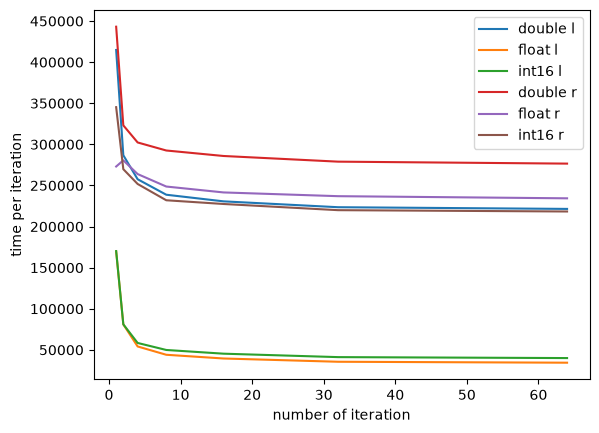

In [156]:
fig, ax = plt.subplots()
plt.plot(iter,times[0]/iter, label="double l")
plt.plot(iter,times[1]/iter, label="float l")
plt.plot(iter,times[2]/iter, label="int16 l")
plt.plot(iter,times[9]/iter, label="double r")
plt.plot(iter,times[10]/iter, label="float r")
plt.plot(iter,times[11]/iter, label="int16 r")
ax.legend(loc='upper right')
ax.set_xlabel('number of iteration')
ax.set_ylabel('time per iteration')
plt.show()

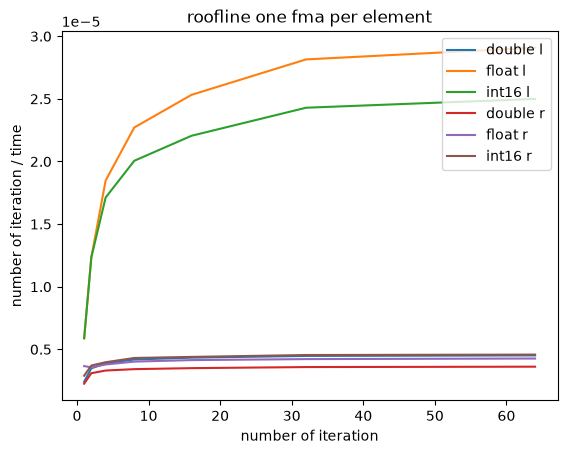

In [157]:
fig, ax = plt.subplots()
plt.plot(iter,iter/times[0], label="double l")
plt.plot(iter,iter/times[1], label="float l")
plt.plot(iter,iter/times[2], label="int16 l")
plt.plot(iter,iter/times[9], label="double r")
plt.plot(iter,iter/times[10], label="float r")
plt.plot(iter,iter/times[11], label="int16 r")
ax.legend(loc='upper right')
ax.set_title('roofline one fma per element')
ax.set_xlabel('number of iteration')
ax.set_ylabel('number of iteration / time')
plt.show()

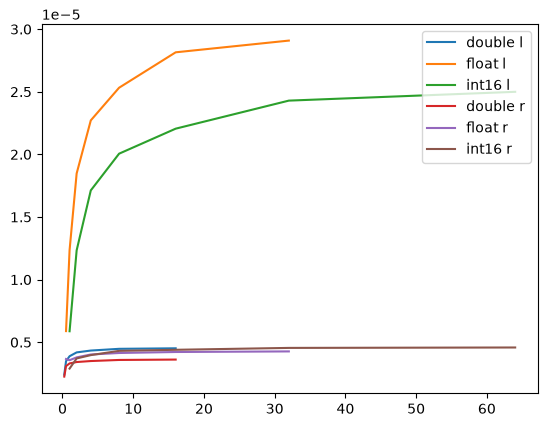

In [158]:
fig, ax = plt.subplots()
plt.plot(iter/4,iter/times[0], label="double l")
plt.plot(iter/2,iter/times[1], label="float l")
plt.plot(iter,iter/times[2], label="int16 l")
plt.plot(iter/4,iter/times[9], label="double r")
plt.plot(iter/2,iter/times[10], label="float r")
plt.plot(iter,iter/times[11], label="int16 r")
ax.legend(loc='upper right')
plt.show()

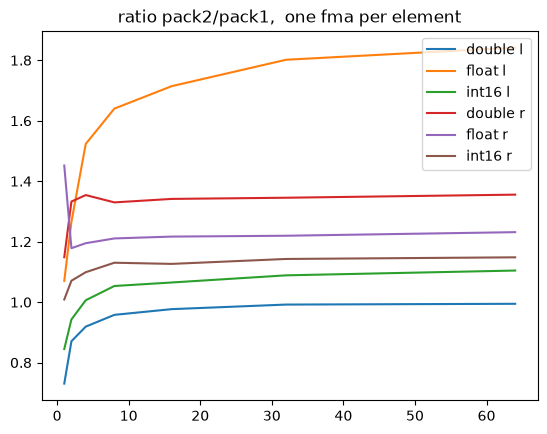

In [159]:
fig, ax = plt.subplots()
plt.plot(iter,times[3+0]/times[0], label="double l")
plt.plot(iter,times[3+1]/times[1], label="float l")
plt.plot(iter,times[3+2]/times[2], label="int16 l")
plt.plot(iter,times[3+9]/times[9], label="double r")
plt.plot(iter,times[3+10]/times[10], label="float r")
plt.plot(iter,times[3+11]/times[11], label="int16 r")
ax.legend(loc='upper right')
ax.set_title('ratio pack2/pack1,  one fma per element')
plt.show()

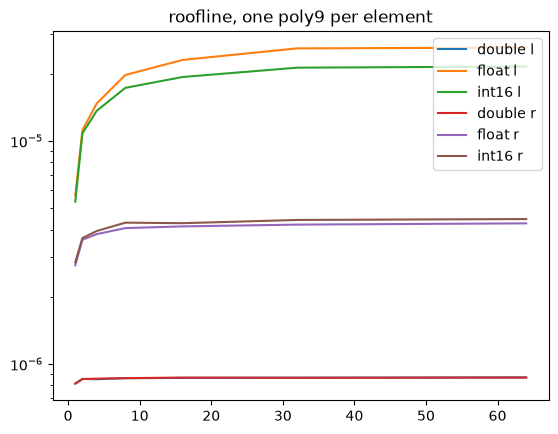

In [160]:
fig, ax = plt.subplots()
plt.plot(iter,iter/times[15], label="double l")
plt.plot(iter,iter/times[16], label="float l")
plt.plot(iter,iter/times[17], label="int16 l")
plt.plot(iter,iter/times[21], label="double r")
plt.plot(iter,iter/times[22], label="float r")
plt.plot(iter,iter/times[23], label="int16 r")
ax.legend(loc='upper right')
plt.yscale("log")
#plt.ylim(10**-8,0.1)
ax.set_title('roofline, one poly9 per element')
plt.show()

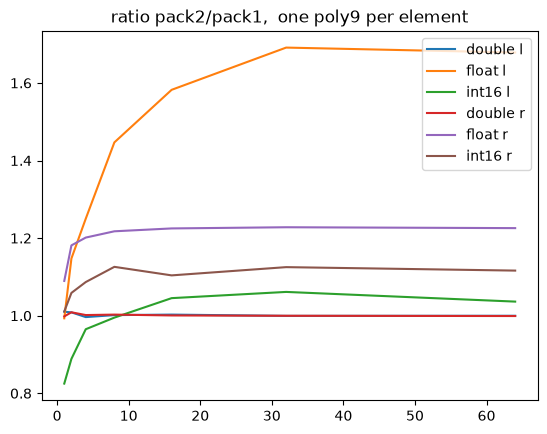

In [161]:
fig, ax = plt.subplots()
plt.plot(iter,times[3+15]/times[15], label="double l")
plt.plot(iter,times[3+16]/times[16], label="float l")
plt.plot(iter,times[3+17]/times[17], label="int16 l")
plt.plot(iter,times[3+21]/times[21], label="double r")
plt.plot(iter,times[3+22]/times[22], label="float r")
plt.plot(iter,times[3+23]/times[23], label="int16 r")
ax.set_title('ratio pack2/pack1,  one poly9 per element')
ax.legend(loc='upper right')
plt.show()

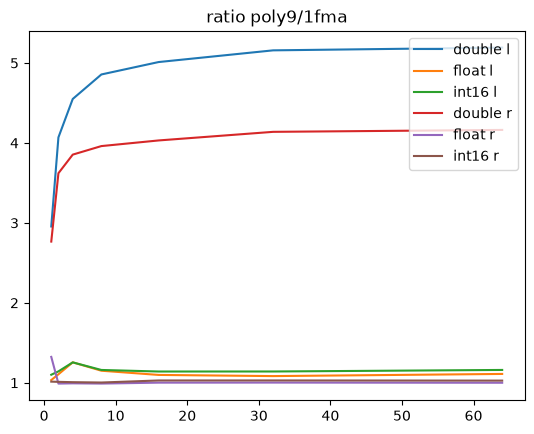

In [162]:
fig, ax = plt.subplots()
plt.plot(iter,times[15]/times[0], label="double l")
plt.plot(iter,times[16]/times[1], label="float l")
plt.plot(iter,times[17]/times[2], label="int16 l")
plt.plot(iter,times[21]/times[9], label="double r")
plt.plot(iter,times[22]/times[10], label="float r")
plt.plot(iter,times[23]/times[11], label="int16 r")
ax.set_title('ratio poly9/1fma')
ax.legend(loc='upper right')
plt.show()

```
template<typename T, bool L>
struct W {
   constexpr void operator()(SoA<T>  y, SoA<T> const x, int const * ind, int j, int k, int n) {
     int a;
     int b;
     if constexpr (L) {
       a = max(j-16,0);
       b = min(j+16,n);
     } else {
       int s = n/2;
       a = (j<s) ? max(s+j-16,0) : max(j-s-16,0);
       b = (j<s) ? min(s+j+16,n) : min(j-s+16,n);
     }
     for (int  i =a; i<b; ++i) {
     if constexpr (std::is_floating_point<T>::value)  {
       y.x[j] =  (y.x[j]*T(1.e-12))+(x.x[j]+x.y[i]*x.z[j]);
       y.y[j] =  (y.y[j]*T(1.e-12))+(x.y[j]+x.y[j]*x.x[i]);
       y.z[j] =  (y.z[j]*T(1.e-12))+(x.z[i]+x.x[j]*x.y[j]);
     } else  {
       y.x[j] =  (y.x[j]>>15)+int(float(x.x[j])+float(x.y[i])*float(x.z[j]));
       y.y[j] =  (y.y[j]>>15)+int(float(x.y[j])+float(x.y[j])*float(x.x[i]));
       y.z[j] =  (y.z[j]>>15)+int(float(x.z[i])+float(x.x[j])*float(x.y[j]));
     }
     }
   }
};
```

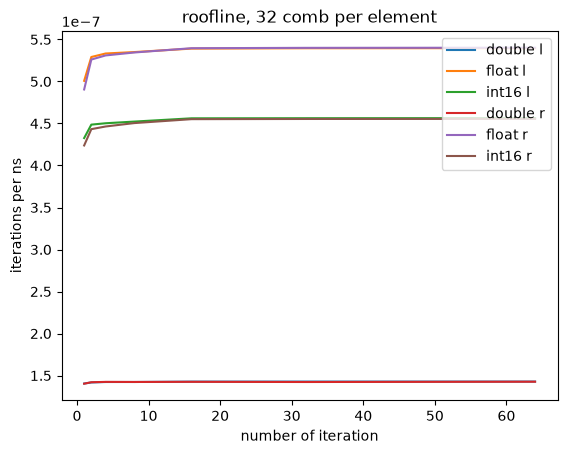

In [163]:
fig, ax = plt.subplots()
plt.plot(iter,iter/times[27], label="double l")
plt.plot(iter,iter/times[28], label="float l")
plt.plot(iter,iter/times[29], label="int16 l")
plt.plot(iter,iter/times[30], label="double r")
plt.plot(iter,iter/times[31], label="float r")
plt.plot(iter,iter/times[32], label="int16 r")
ax.legend(loc='upper right')
# plt.yscale("log")
#plt.ylim(10**-8,0.1)
ax.set_title('roofline, 32 comb per element')
ax.set_xlabel('number of iteration')
ax.set_ylabel('iterations per ns')
plt.show()

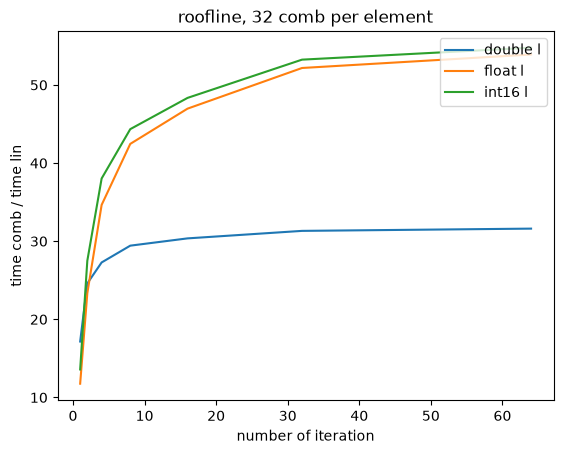

In [165]:
fig, ax = plt.subplots()
plt.plot(iter,times[27]/times[0], label="double l")
plt.plot(iter,times[28]/times[1], label="float l")
plt.plot(iter,times[29]/times[2], label="int16 l")
#plt.plot(iter,times[30]/times[0], label="double r")
#plt.plot(iter,times[31]/times[1], label="float r")
#plt.plot(iter,times[32]/times[2], label="int16 r")
ax.legend(loc='upper right')
# plt.yscale("log")
#plt.ylim(10**-8,0.1)
ax.set_title('roofline, 32 comb per element')
ax.set_xlabel('number of iteration')
ax.set_ylabel('time comb / time lin')
plt.show()